In [120]:
# ============================================================
# STUDENT PLACEMENT PREDICTION
# Logistic Regression
# ============================================================


# ============================================================
# 1. Import Libraries
# ============================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)


# ============================================================
# 2. Load Dataset
# ============================================================

df = pd.read_csv("cleaned_student_placement.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

print("\nFirst 5 rows:")
print(df.head())


# ============================================================
# 3. Check Dataset Information
# ============================================================

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())


# ============================================================
# 4. Remove Missing Values
# ============================================================

df = df.dropna()

print("\nShape after removing missing values:")
print(df.shape)


# ============================================================
# 5. Define Target Column
# ============================================================

target_column = "PlacementStatus"

print("\nTarget Column:")
print(target_column)

print("\nMissing values in target:")
print(df[target_column].isnull().sum())

print("\nTarget values:")
print(df[target_column].value_counts(dropna=False))


# ============================================================
# Create Features (X) and Target (y)
# ============================================================

X = df.drop(target_column, axis=1)
y = df[target_column]

# ============================================================
# 6. Convert Target to 1/0
# ============================================================

# Your dataset contains:
# NotPlaced = 0
# Placed = 1

y = y.astype(str).str.strip()

y = y.map({
    "NotPlaced": 0,
    "Placed": 1
})

# Check for any values that were not converted
print("\nTarget values after conversion:")
print(y.value_counts(dropna=False))

print("\nMissing target values after conversion:")
print(y.isnull().sum())

# Remove rows with invalid/missing target values
valid_rows = y.notna()

X = X.loc[valid_rows].copy()
y = y.loc[valid_rows].copy()

# Convert target to integer
y = y.astype(int)

# Final check
print("\n================================")
print("FINAL TARGET CHECK")
print("================================")

print("Target distribution:")
print(y.value_counts())

print("\nTarget classes:")
print(sorted(y.unique()))

print("\nNumber of classes:", y.nunique())

if y.nunique() < 2:
    raise ValueError(
        "Target still contains fewer than 2 classes."
    )

print("\nTarget contains both classes. Ready for model training!")

# ============================================================
# 7. Identify Numerical and Categorical Columns
# ============================================================

numerical_columns = X.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_columns = X.select_dtypes(
    include=["object", "category", "bool"]
).columns


print("\nNumerical Columns:")
print(list(numerical_columns))

print("\nCategorical Columns:")
print(list(categorical_columns))


# ============================================================
# 8. Preprocessing
# ============================================================

preprocessor = ColumnTransformer(
    transformers=[

        # Scale numerical data
        (
            "numerical",
            StandardScaler(),
            numerical_columns
        ),

        # Convert categorical data into numbers
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_columns
        )
    ]
)


# ============================================================
# 9. Create Logistic Regression Pipeline
# ============================================================

model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),

    (
        "classifier",
        LogisticRegression(
            max_iter=1000
        )
    )
])


# Keep the Week 4 model available for Week 5
baseline_model = model


# ============================================================
# 10. Train-Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


print("\nTraining Data:", X_train.shape)
print("Testing Data:", X_test.shape)


# ============================================================
# 11. Train Model
# ============================================================

model.fit(
    X_train,
    y_train
)

print("\nModel trained successfully!")


# ============================================================
# 12. Make Predictions
# ============================================================

y_pred = model.predict(X_test)

print("\nPredictions generated successfully!")


# ============================================================
# 13. Accuracy
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\n================================")
print("MODEL ACCURACY")
print("================================")

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)


# ============================================================
# 14. Classification Report
# ============================================================

print("\n================================")
print("CLASSIFICATION REPORT")
print("================================")

print(
    classification_report(
        y_test,
        y_pred
    )
)


# ============================================================
# 15. Confusion Matrix
# ============================================================

print("\n================================")
print("CONFUSION MATRIX")
print("================================")

cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)


# ============================================================
# Verify Model for Week 5
# ============================================================

print("\n================================")
print("WEEK 5 MODEL VERIFICATION")
print("================================")

print("\nFinal Model:")
print(baseline_model)

print("\nTraining samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("\nTarget distribution:")
print(y.value_counts())

Dataset loaded successfully!
Shape: (10000, 12)

First 5 rows:
   StudentID  CGPA  Internships  Projects  Workshops/Certifications  \
0          1   7.5            1         1                         1   
1          2   8.9            0         3                         2   
2          3   7.3            1         2                         2   
3          4   7.5            1         1                         2   
4          5   8.3            1         2                         2   

   AptitudeTestScore  SoftSkillsRating ExtracurricularActivities  \
0                 65               4.4                        No   
1                 90               4.0                       Yes   
2                 82               4.8                       Yes   
3                 85               4.4                       Yes   
4                 86               4.5                       Yes   

  PlacementTraining  SSC_Marks  HSC_Marks PlacementStatus  
0                No         61         79

In [121]:
print("Column names in your dataset:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head())

Column names in your dataset:
['StudentID', 'CGPA', 'Internships', 'Projects', 'Workshops/Certifications', 'AptitudeTestScore', 'SoftSkillsRating', 'ExtracurricularActivities', 'PlacementTraining', 'SSC_Marks', 'HSC_Marks', 'PlacementStatus']

First 5 rows:
   StudentID  CGPA  Internships  Projects  Workshops/Certifications  \
0          1   7.5            1         1                         1   
1          2   8.9            0         3                         2   
2          3   7.3            1         2                         2   
3          4   7.5            1         1                         2   
4          5   8.3            1         2                         2   

   AptitudeTestScore  SoftSkillsRating ExtracurricularActivities  \
0                 65               4.4                        No   
1                 90               4.0                       Yes   
2                 82               4.8                       Yes   
3                 85               4.4     

In [122]:
target_column = "PlacementStatus"

In [123]:
print("Rows and Columns:", df.shape)
print("Columns:", df.columns.tolist())

Rows and Columns: (10000, 12)
Columns: ['StudentID', 'CGPA', 'Internships', 'Projects', 'Workshops/Certifications', 'AptitudeTestScore', 'SoftSkillsRating', 'ExtracurricularActivities', 'PlacementTraining', 'SSC_Marks', 'HSC_Marks', 'PlacementStatus']


In [124]:
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())

StudentID                      int64
CGPA                         float64
Internships                    int64
Projects                       int64
Workshops/Certifications       int64
AptitudeTestScore              int64
SoftSkillsRating             float64
ExtracurricularActivities     object
PlacementTraining             object
SSC_Marks                      int64
HSC_Marks                      int64
PlacementStatus               object
dtype: object

Missing values:
StudentID                    0
CGPA                         0
Internships                  0
Projects                     0
Workshops/Certifications     0
AptitudeTestScore            0
SoftSkillsRating             0
ExtracurricularActivities    0
PlacementTraining            0
SSC_Marks                    0
HSC_Marks                    0
PlacementStatus              0
dtype: int64


In [125]:
# 3. Check Dataset Information

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

# Check placement distribution
print("\nPlacement Distribution:")
print(df["PlacementStatus"].value_counts())


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   StudentID                  10000 non-null  int64  
 1   CGPA                       10000 non-null  float64
 2   Internships                10000 non-null  int64  
 3   Projects                   10000 non-null  int64  
 4   Workshops/Certifications   10000 non-null  int64  
 5   AptitudeTestScore          10000 non-null  int64  
 6   SoftSkillsRating           10000 non-null  float64
 7   ExtracurricularActivities  10000 non-null  object 
 8   PlacementTraining          10000 non-null  object 
 9   SSC_Marks                  10000 non-null  int64  
 10  HSC_Marks                  10000 non-null  int64  
 11  PlacementStatus            10000 non-null  object 
dtypes: float64(2), int64(7), object(3)
memory usage: 937.6+ KB
None

Missing Values:


In [126]:
# ============================================
# 16. BASELINE BENCHMARK
# ============================================

from sklearn.dummy import DummyClassifier

dummy_model = DummyClassifier(
    strategy="most_frequent"
)

dummy_model.fit(X_train, y_train)

dummy_pred = dummy_model.predict(X_test)

dummy_accuracy = accuracy_score(
    y_test,
    dummy_pred
)

print("\n================================")
print("BASELINE BENCHMARK")
print("================================")

print("Dummy Classifier Accuracy:",
      dummy_accuracy)

print("Dummy Classifier Accuracy (%):",
      dummy_accuracy * 100)

print("\nLogistic Regression Accuracy:",
      accuracy)

print("Logistic Regression Accuracy (%):",
      accuracy * 100)


BASELINE BENCHMARK
Dummy Classifier Accuracy: 0.5805
Dummy Classifier Accuracy (%): 58.050000000000004

Logistic Regression Accuracy: 0.807
Logistic Regression Accuracy (%): 80.7


In [127]:
df = pd.read_csv("cleaned_student_placement.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (10000, 12)


,StudentID,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus
0,1,7.5,1,1,1,65,4.4,No,No,61,79,NotPlaced
1,2,8.9,0,3,2,90,4.0,Yes,Yes,78,82,Placed
2,3,7.3,1,2,2,82,4.8,Yes,No,79,80,NotPlaced
3,4,7.5,1,1,2,85,4.4,Yes,Yes,81,80,Placed
4,5,8.3,1,2,2,86,4.5,Yes,Yes,74,88,Placed


In [128]:
import pandas as pd
import numpy as np

In [129]:
df = pd.read_csv("cleaned_student_placement.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (10000, 12)


,StudentID,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus
0,1,7.5,1,1,1,65,4.4,No,No,61,79,NotPlaced
1,2,8.9,0,3,2,90,4.0,Yes,Yes,78,82,Placed
2,3,7.3,1,2,2,82,4.8,Yes,No,79,80,NotPlaced
3,4,7.5,1,1,2,85,4.4,Yes,Yes,81,80,Placed
4,5,8.3,1,2,2,86,4.5,Yes,Yes,74,88,Placed


In [130]:
print("Column Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info() 
print("\nMissing Values:")
print(df.isnull().sum())
print("\nDuplicate Rows:")
print(df.duplicated().sum())
print("\nPlacement Status Distribution:")
print(df["PlacementStatus"].value_counts())

Column Names:
['StudentID', 'CGPA', 'Internships', 'Projects', 'Workshops/Certifications', 'AptitudeTestScore', 'SoftSkillsRating', 'ExtracurricularActivities', 'PlacementTraining', 'SSC_Marks', 'HSC_Marks', 'PlacementStatus']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   StudentID                  10000 non-null  int64  
 1   CGPA                       10000 non-null  float64
 2   Internships                10000 non-null  int64  
 3   Projects                   10000 non-null  int64  
 4   Workshops/Certifications   10000 non-null  int64  
 5   AptitudeTestScore          10000 non-null  int64  
 6   SoftSkillsRating           10000 non-null  float64
 7   ExtracurricularActivities  10000 non-null  object 
 8   PlacementTraining          10000 non-null  object 
 9   SSC_Marks             

In [131]:
X = df.drop(["StudentID", "PlacementStatus"], axis=1)

y = df["PlacementStatus"]

print("Features (X):")
print(X.columns.tolist())

print("\nTarget (y):")
print(y.value_counts())

Features (X):
['CGPA', 'Internships', 'Projects', 'Workshops/Certifications', 'AptitudeTestScore', 'SoftSkillsRating', 'ExtracurricularActivities', 'PlacementTraining', 'SSC_Marks', 'HSC_Marks']

Target (y):
PlacementStatus
NotPlaced    5803
Placed       4197
Name: count, dtype: int64


In [132]:
y = y.map({
    "Placed": 1,
    "NotPlaced": 0
})

print(y.value_counts())

PlacementStatus
0    5803
1    4197
Name: count, dtype: int64


In [133]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = X.select_dtypes(
    include=["object", "category", "bool"]
).columns

print("Numerical Features:")
print(list(numeric_features))

print("\nCategorical Features:")
print(list(categorical_features))

Numerical Features:
['CGPA', 'Internships', 'Projects', 'Workshops/Certifications', 'AptitudeTestScore', 'SoftSkillsRating', 'SSC_Marks', 'HSC_Marks']

Categorical Features:
['ExtracurricularActivities', 'PlacementTraining']


In [134]:
#Splitting the data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 8000
Testing samples: 2000


In [135]:
#preprocessing
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [136]:
#Baseline model
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

baseline_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

print("Baseline model created successfully!")



Baseline model created successfully!


In [137]:
#train and Prediction
baseline_model.fit(X_train, y_train)
print("Baseline Logistic Regression trained successfully!")

y_pred = baseline_model.predict(X_test)

print("Predictions generated successfully!")

Baseline Logistic Regression trained successfully!
Predictions generated successfully!


In [138]:
#Baseline metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("===== WEEK 3 BASELINE RESULTS =====")
print("Accuracy :", round(accuracy * 100, 2), "%")
print("Precision:", round(precision * 100, 2), "%")
print("Recall   :", round(recall * 100, 2), "%")
print("F1 Score :", round(f1 * 100, 2), "%")

===== WEEK 3 BASELINE RESULTS =====
Accuracy : 80.85 %
Precision: 76.95 %
Recall   : 77.59 %
F1 Score : 77.27 %


In [139]:
#Classification Report  and confusion matrics
print("\n===== CLASSIFICATION REPORT =====")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Not Placed", "Placed"]
    )
)
cm = confusion_matrix(y_test, y_pred)

print("\n===== CONFUSION MATRIX =====")
print(cm)


===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

  Not Placed       0.84      0.83      0.83      1161
      Placed       0.77      0.78      0.77       839

    accuracy                           0.81      2000
   macro avg       0.80      0.80      0.80      2000
weighted avg       0.81      0.81      0.81      2000


===== CONFUSION MATRIX =====
[[966 195]
 [188 651]]


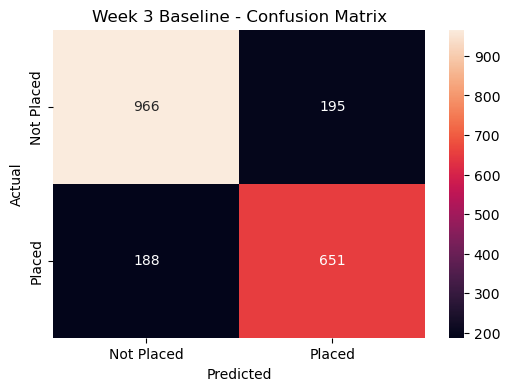

In [140]:
#Visialisation
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Not Placed", "Placed"],
    yticklabels=["Not Placed", "Placed"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Week 3 Baseline - Confusion Matrix")
plt.show()

In [141]:
#Week 3 ended at all then for now week 4 processing
print("Numerical Features:")
print(list(numeric_features))

Numerical Features:
['CGPA', 'Internships', 'Projects', 'Workshops/Certifications', 'AptitudeTestScore', 'SoftSkillsRating', 'SSC_Marks', 'HSC_Marks']


In [142]:
#interation feature
from sklearn.preprocessing import PolynomialFeatures

interaction_transformer = PolynomialFeatures(
    degree=2,
    interaction_only=True,
    include_bias=False
)

print("Interaction feature transformer created successfully!")

Interaction feature transformer created successfully!


In [143]:
#Week 4 pipeline
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

week4_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("interaction", PolynomialFeatures(
                    degree=2,
                    interaction_only=True,
                    include_bias=False
                )),
                ("scaler", StandardScaler())
            ]),
            numeric_features
        ),

        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

print("Week 4 feature engineering pipeline created!")

Week 4 feature engineering pipeline created!


In [144]:
#Training of improved logistic regression
week4_lr = Pipeline(
    steps=[
        ("preprocessor", week4_preprocessor),
        ("classifier", LogisticRegression(max_iter=2000))
    ]
)
print("Week 4 Logistic Regression created!")

week4_lr.fit(X_train, y_train)
print("Week 4 Logistic Regression trained successfully!")

y_pred_week4 = week4_lr.predict(X_test)
print("Predictions generated successfully!")

accuracy_week4 = accuracy_score(y_test, y_pred_week4)
precision_week4 = precision_score(y_test, y_pred_week4)
recall_week4 = recall_score(y_test, y_pred_week4)
f1_week4 = f1_score(y_test, y_pred_week4)

print("===== WEEK 4 FEATURE ENGINEERED MODEL =====")
print("Accuracy :", round(accuracy_week4 * 100, 2), "%")
print("Precision:", round(precision_week4 * 100, 2), "%")
print("Recall   :", round(recall_week4 * 100, 2), "%")
print("F1 Score :", round(f1_week4 * 100, 2), "%")

Week 4 Logistic Regression created!
Week 4 Logistic Regression trained successfully!
Predictions generated successfully!
===== WEEK 4 FEATURE ENGINEERED MODEL =====
Accuracy : 80.25 %
Precision: 77.14 %
Recall   : 75.21 %
F1 Score : 76.16 %


In [145]:
#Comparision of week 3 and week 4
comparison = pd.DataFrame({
    "Model": [
        "Week 3 Baseline",
        "Week 4 Feature Engineered"
    ],
    
    "Accuracy": [
        accuracy,
        accuracy_week4
    ],
    
    "Precision": [
        precision,
        precision_week4
    ],
    
    "Recall": [
        recall,
        recall_week4
    ],
    
    "F1 Score": [
        f1,
        f1_week4
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Week 3 Baseline,0.8085,0.769504,0.775924,0.772700
1,Week 4 Feature Engineered,0.8025,0.771394,0.752086,0.761617


[[974 187]
 [208 631]]


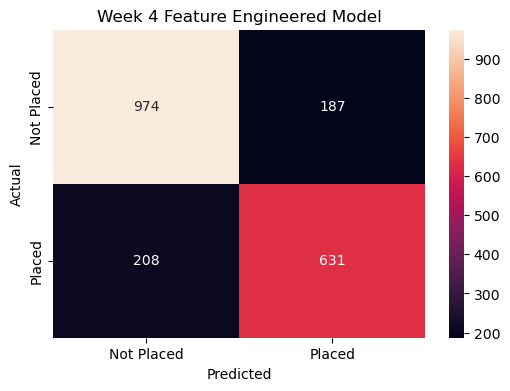

In [146]:
#Confusion matrics for week 4
cm_week4 = confusion_matrix(y_test, y_pred_week4)
print(cm_week4)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_week4,
    annot=True,
    fmt="d",
    xticklabels=["Not Placed", "Placed"],
    yticklabels=["Not Placed", "Placed"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Week 4 Feature Engineered Model")

plt.show()

In [147]:
# ============================================
# HYPERPARAMETER TUNING - LOGISTIC REGRESSION
# ============================================

from sklearn.model_selection import GridSearchCV

param_grid_lr = {
    "classifier__C": [0.01, 0.1, 1, 10, 100],
    "classifier__solver": ["liblinear", "lbfgs"]
}

print("Parameter grid created:")
print(param_grid_lr)

grid_lr = GridSearchCV(
    estimator=week4_lr,
    param_grid=param_grid_lr,
    cv=5,
    scoring="f1",
    n_jobs=1,          # Changed from -1 to 1
    verbose=1
)

print("GridSearchCV created successfully!")

grid_lr.fit(X_train, y_train)

print("\nGridSearchCV completed successfully!")

Parameter grid created:
{'classifier__C': [0.01, 0.1, 1, 10, 100], 'classifier__solver': ['liblinear', 'lbfgs']}
GridSearchCV created successfully!
Fitting 5 folds for each of 10 candidates, totalling 50 fits

GridSearchCV completed successfully!


In [148]:
print("Best Parameters:")
print(grid_lr.best_params_)
print("Best Cross-Validation F1 Score:")
print(round(grid_lr.best_score_, 4))

Best Parameters:
{'classifier__C': 1, 'classifier__solver': 'liblinear'}
Best Cross-Validation F1 Score:
0.7567


In [149]:
# ============================================
# TUNED LOGISTIC REGRESSION - RESULTS
# ============================================

# Get the best model found by GridSearchCV
best_lr = grid_lr.best_estimator_

# Make predictions on test data
y_pred_tuned_lr = best_lr.predict(X_test)

print("Tuned Logistic Regression predictions generated successfully!")

# ============================================
# Calculating the results
# ============================================

tuned_lr_accuracy = accuracy_score(
    y_test,
    y_pred_tuned_lr
)

tuned_lr_precision = precision_score(
    y_test,
    y_pred_tuned_lr
)

tuned_lr_recall = recall_score(
    y_test,
    y_pred_tuned_lr
)

tuned_lr_f1 = f1_score(
    y_test,
    y_pred_tuned_lr
)

# ============================================
# Display results
# ============================================

print("\n===== TUNED LOGISTIC REGRESSION =====")

print(
    "Accuracy :",
    round(tuned_lr_accuracy * 100, 2),
    "%"
)

print(
    "Precision:",
    round(tuned_lr_precision * 100, 2),
    "%"
)

print(
    "Recall   :",
    round(tuned_lr_recall * 100, 2),
    "%"
)

print(
    "F1 Score :",
    round(tuned_lr_f1 * 100, 2),
    "%"
)

Tuned Logistic Regression predictions generated successfully!

===== TUNED LOGISTIC REGRESSION =====
Accuracy : 80.2 %
Precision: 77.05 %
Recall   : 75.21 %
F1 Score : 76.12 %


In [150]:
# Get the best model found by GridSearchCV
best_lr = grid_lr.best_estimator_

# Make predictions on the test data
y_pred_tuned_lr = best_lr.predict(X_test)

print("Tuned Logistic Regression predictions generated successfully!")

Tuned Logistic Regression predictions generated successfully!


In [151]:
# Calculating the results

tuned_lr_accuracy = accuracy_score(y_test, y_pred_tuned_lr)
tuned_lr_precision = precision_score(y_test, y_pred_tuned_lr)
tuned_lr_recall = recall_score(y_test, y_pred_tuned_lr)
tuned_lr_f1 = f1_score(y_test, y_pred_tuned_lr)

print("===== TUNED LOGISTIC REGRESSION =====")
print("Accuracy :", round(tuned_lr_accuracy * 100, 2), "%")
print("Precision:", round(tuned_lr_precision * 100, 2), "%")
print("Recall   :", round(tuned_lr_recall * 100, 2), "%")
print("F1 Score :", round(tuned_lr_f1 * 100, 2), "%")

===== TUNED LOGISTIC REGRESSION =====
Accuracy : 80.2 %
Precision: 77.05 %
Recall   : 75.21 %
F1 Score : 76.12 %


In [152]:
comparison = pd.DataFrame({
    "Model": [
        "Week 3 Baseline",
        "Week 4 Feature Engineered",
        "Week 4 Tuned Logistic Regression"
    ],

    "Accuracy": [
        accuracy,
        accuracy_week4,
        tuned_lr_accuracy
    ],

    "Precision": [
        precision,
        precision_week4,
        tuned_lr_precision
    ],

    "Recall": [
        recall,
        recall_week4,
        tuned_lr_recall
    ],

    "F1 Score": [
        f1,
        f1_week4,
        tuned_lr_f1
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Week 3 Baseline,0.8085,0.769504,0.775924,0.772700
1,Week 4 Feature Engineered,0.8025,0.771394,0.752086,0.761617
2,Week 4 Tuned Logistic Regression,0.8020,0.770452,0.752086,0.761158


In [153]:
#Now Random Forest
from sklearn.ensemble import RandomForestClassifier
print("Random Forest imported successfully!")

Random Forest imported successfully!


In [154]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", week4_preprocessor),
        ("classifier", RandomForestClassifier(
            random_state=42
        ))
    ]
)

print("Random Forest model created successfully!")

Random Forest model created successfully!


In [155]:
rf_model.fit(X_train, y_train)
print("Random Forest trained successfully!")

y_pred_rf = rf_model.predict(X_test)
print("Random Forest predictions generated!")

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

print("===== RANDOM FOREST =====")
print("Accuracy :", round(rf_accuracy * 100, 2), "%")
print("Precision:", round(rf_precision * 100, 2), "%")
print("Recall   :", round(rf_recall * 100, 2), "%")
print("F1 Score :", round(rf_f1 * 100, 2), "%")

Random Forest trained successfully!
Random Forest predictions generated!
===== RANDOM FOREST =====
Accuracy : 79.45 %
Precision: 76.88 %
Recall   : 72.94 %
F1 Score : 74.86 %


In [156]:
#tuning of random forest
rf_param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [None, 10, 20],
    "classifier__min_samples_split": [2, 5, 10]
}

print("Random Forest parameter grid created!")
print(rf_param_grid)

grid_rf = GridSearchCV(
    estimator=rf_model,
    param_grid=rf_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

print("Random Forest GridSearchCV created!")

grid_rf.fit(X_train, y_train)
print("===== BEST RANDOM FOREST PARAMETERS =====")
print(grid_rf.best_params_)
print("===== BEST CROSS-VALIDATION F1 SCORE =====")
print(round(grid_rf.best_score_, 4))
best_rf = grid_rf.best_estimator_

print("Best Random Forest model selected!")
y_pred_tuned_rf = best_rf.predict(X_test)

print("Tuned Random Forest predictions generated!")

Random Forest parameter grid created!
{'classifier__n_estimators': [100, 200], 'classifier__max_depth': [None, 10, 20], 'classifier__min_samples_split': [2, 5, 10]}
Random Forest GridSearchCV created!
Fitting 5 folds for each of 18 candidates, totalling 90 fits
===== BEST RANDOM FOREST PARAMETERS =====
{'classifier__max_depth': 10, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 100}
===== BEST CROSS-VALIDATION F1 SCORE =====
0.7457
Best Random Forest model selected!
Tuned Random Forest predictions generated!


In [157]:
tuned_rf_accuracy = accuracy_score(y_test, y_pred_tuned_rf)
tuned_rf_precision = precision_score(y_test, y_pred_tuned_rf)
tuned_rf_recall = recall_score(y_test, y_pred_tuned_rf)
tuned_rf_f1 = f1_score(y_test, y_pred_tuned_rf)

print("===== TUNED RANDOM FOREST =====")
print("Accuracy :", round(tuned_rf_accuracy * 100, 2), "%")
print("Precision:", round(tuned_rf_precision * 100, 2), "%")
print("Recall   :", round(tuned_rf_recall * 100, 2), "%")
print("F1 Score :", round(tuned_rf_f1 * 100, 2), "%")

===== TUNED RANDOM FOREST =====
Accuracy : 79.95 %
Precision: 77.31 %
Recall   : 73.9 %
F1 Score : 75.56 %


In [158]:
#SVM NOW
from sklearn.svm import SVC
svm_model = Pipeline(
    steps=[
        ("preprocessor", week4_preprocessor),
        ("classifier", SVC())
    ]
)
print("SVM model created successfully!")
svm_model.fit(X_train, y_train)
print("SVM trained successfully!")

y_pred_svm = svm_model.predict(X_test)
print("SVM predictions generated!")

svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_precision = precision_score(y_test, y_pred_svm)
svm_recall = recall_score(y_test, y_pred_svm)
svm_f1 = f1_score(y_test, y_pred_svm)

print("===== DEFAULT SVM =====")
print("Accuracy :", round(svm_accuracy * 100, 2), "%")
print("Precision:", round(svm_precision * 100, 2), "%")
print("Recall   :", round(svm_recall * 100, 2), "%")
print("F1 Score :", round(svm_f1 * 100, 2), "%")

SVM model created successfully!
SVM trained successfully!
SVM predictions generated!
===== DEFAULT SVM =====
Accuracy : 80.65 %
Precision: 77.83 %
Recall   : 75.33 %
F1 Score : 76.56 %


In [159]:
#SVM hyper parameter tuning
svm_param_grid = {
    "classifier__C": [0.1, 1, 10],
    "classifier__kernel": ["linear", "rbf"],
    "classifier__gamma": ["scale", "auto"]
}

print("SVM parameter grid created!")
print(svm_param_grid)

grid_svm = GridSearchCV(
    estimator=svm_model,
    param_grid=svm_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

print("SVM GridSearchCV created!")
grid_svm.fit(X_train, y_train)
print("===== BEST SVM PARAMETERS =====")
print(grid_svm.best_params_)
print("===== BEST SVM CROSS-VALIDATION F1 =====")
print(round(grid_svm.best_score_, 4))
best_svm = grid_svm.best_estimator_
print("Best SVM model selected!")
y_pred_tuned_svm = best_svm.predict(X_test)
print("Tuned SVM predictions generated!")

tuned_svm_accuracy = accuracy_score(y_test, y_pred_tuned_svm)
tuned_svm_precision = precision_score(y_test, y_pred_tuned_svm)
tuned_svm_recall = recall_score(y_test, y_pred_tuned_svm)
tuned_svm_f1 = f1_score(y_test, y_pred_tuned_svm)

print("===== TUNED SVM =====")
print("Accuracy :", round(tuned_svm_accuracy * 100, 2), "%")
print("Precision:", round(tuned_svm_precision * 100, 2), "%")
print("Recall   :", round(tuned_svm_recall * 100, 2), "%")
print("F1 Score :", round(tuned_svm_f1 * 100, 2), "%")

SVM parameter grid created!
{'classifier__C': [0.1, 1, 10], 'classifier__kernel': ['linear', 'rbf'], 'classifier__gamma': ['scale', 'auto']}
SVM GridSearchCV created!
Fitting 5 folds for each of 12 candidates, totalling 60 fits
===== BEST SVM PARAMETERS =====
{'classifier__C': 0.1, 'classifier__gamma': 'scale', 'classifier__kernel': 'linear'}
===== BEST SVM CROSS-VALIDATION F1 =====
0.7554
Best SVM model selected!
Tuned SVM predictions generated!
===== TUNED SVM =====
Accuracy : 80.15 %
Precision: 77.15 %
Recall   : 74.85 %
F1 Score : 75.98 %


In [160]:
#KNN
from sklearn.neighbors import KNeighborsClassifier
knn_model = Pipeline(
    steps=[
        ("preprocessor", week4_preprocessor),
        ("classifier", KNeighborsClassifier())
    ]
)

print("KNN model created successfully!")
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)

knn_accuracy = accuracy_score(y_test, y_pred_knn)
knn_precision = precision_score(y_test, y_pred_knn)
knn_recall = recall_score(y_test, y_pred_knn)
knn_f1 = f1_score(y_test, y_pred_knn)

print("===== DEFAULT KNN =====")
print("Accuracy :", round(knn_accuracy * 100, 2), "%")
print("Precision:", round(knn_precision * 100, 2), "%")
print("Recall   :", round(knn_recall * 100, 2), "%")
print("F1 Score :", round(knn_f1 * 100, 2), "%")

KNN model created successfully!
===== DEFAULT KNN =====
Accuracy : 77.6 %
Precision: 74.29 %
Recall   : 71.28 %
F1 Score : 72.75 %


In [161]:
#KNN Hypermeter tuning
knn_param_grid = {
    "classifier__n_neighbors": [3, 5, 7, 9, 11, 15],
    "classifier__weights": ["uniform", "distance"],
    "classifier__metric": ["euclidean", "manhattan"]
}

print("KNN parameter grid created!")
print(knn_param_grid)

grid_knn = GridSearchCV(
    estimator=knn_model,
    param_grid=knn_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

print("KNN GridSearchCV created!")

grid_knn.fit(X_train, y_train)
print("===== BEST KNN PARAMETERS =====")
print(grid_knn.best_params_)
print("===== BEST KNN CROSS-VALIDATION F1 =====")
print(round(grid_knn.best_score_, 4))
best_knn = grid_knn.best_estimator_
print("Best KNN model selected!")
y_pred_tuned_knn = best_knn.predict(X_test)
print("Tuned KNN predictions generated!")

tuned_knn_accuracy = accuracy_score(y_test, y_pred_tuned_knn)
tuned_knn_precision = precision_score(y_test, y_pred_tuned_knn)
tuned_knn_recall = recall_score(y_test, y_pred_tuned_knn)
tuned_knn_f1 = f1_score(y_test, y_pred_tuned_knn)

print("===== TUNED KNN =====")
print("Accuracy :", round(tuned_knn_accuracy * 100, 2), "%")
print("Precision:", round(tuned_knn_precision * 100, 2), "%")
print("Recall   :", round(tuned_knn_recall * 100, 2), "%")
print("F1 Score :", round(tuned_knn_f1 * 100, 2), "%")

KNN parameter grid created!
{'classifier__n_neighbors': [3, 5, 7, 9, 11, 15], 'classifier__weights': ['uniform', 'distance'], 'classifier__metric': ['euclidean', 'manhattan']}
KNN GridSearchCV created!
Fitting 5 folds for each of 24 candidates, totalling 120 fits
===== BEST KNN PARAMETERS =====
{'classifier__metric': 'manhattan', 'classifier__n_neighbors': 15, 'classifier__weights': 'uniform'}
===== BEST KNN CROSS-VALIDATION F1 =====
0.7417
Best KNN model selected!
Tuned KNN predictions generated!
===== TUNED KNN =====
Accuracy : 79.35 %
Precision: 75.24 %
Recall   : 75.69 %
F1 Score : 75.46 %


In [162]:
final_results = pd.DataFrame({
    "Model": [
        "Week 3 Baseline Logistic Regression",
        "Feature Engineered Logistic Regression",
        "Tuned Logistic Regression",
        "Default Random Forest",
        "Tuned Random Forest",
        "Default SVM",
        "Tuned SVM",
        "Default KNN",
        "Tuned KNN"
    ],

    "Accuracy": [
        accuracy,
        accuracy_week4,
        tuned_lr_accuracy,
        rf_accuracy,
        tuned_rf_accuracy,
        svm_accuracy,
        tuned_svm_accuracy,
        knn_accuracy,
        tuned_knn_accuracy
    ],

    "Precision": [
        precision,
        precision_week4,
        tuned_lr_precision,
        rf_precision,
        tuned_rf_precision,
        svm_precision,
        tuned_svm_precision,
        knn_precision,
        tuned_knn_precision
    ],

    "Recall": [
        recall,
        recall_week4,
        tuned_lr_recall,
        rf_recall,
        tuned_rf_recall,
        svm_recall,
        tuned_svm_recall,
        knn_recall,
        tuned_knn_recall
    ],

    "F1 Score": [
        f1,
        f1_week4,
        tuned_lr_f1,
        rf_f1,
        tuned_rf_f1,
        svm_f1,
        tuned_svm_f1,
        knn_f1,
        tuned_knn_f1
    ]
})

final_results

final_results.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

,Model,Accuracy,Precision,Recall,F1 Score
0,Week 3 Baseline Logistic Regression,0.8085,0.769504,0.775924,0.772700
1,Default SVM,0.8065,0.778325,0.753278,0.765597
2,Feature Engineered Logistic Regression,0.8025,0.771394,0.752086,0.761617
3,Tuned Logistic Regression,0.8020,0.770452,0.752086,0.761158
4,Tuned SVM,0.8015,0.771499,0.748510,0.759831
5,Tuned Random Forest,0.7995,0.773067,0.738975,0.755637
6,Tuned KNN,0.7935,0.752370,0.756853,0.754605
7,Default Random Forest,0.7945,0.768844,0.729440,0.748624
8,Default KNN,0.7760,0.742857,0.712753,0.727494


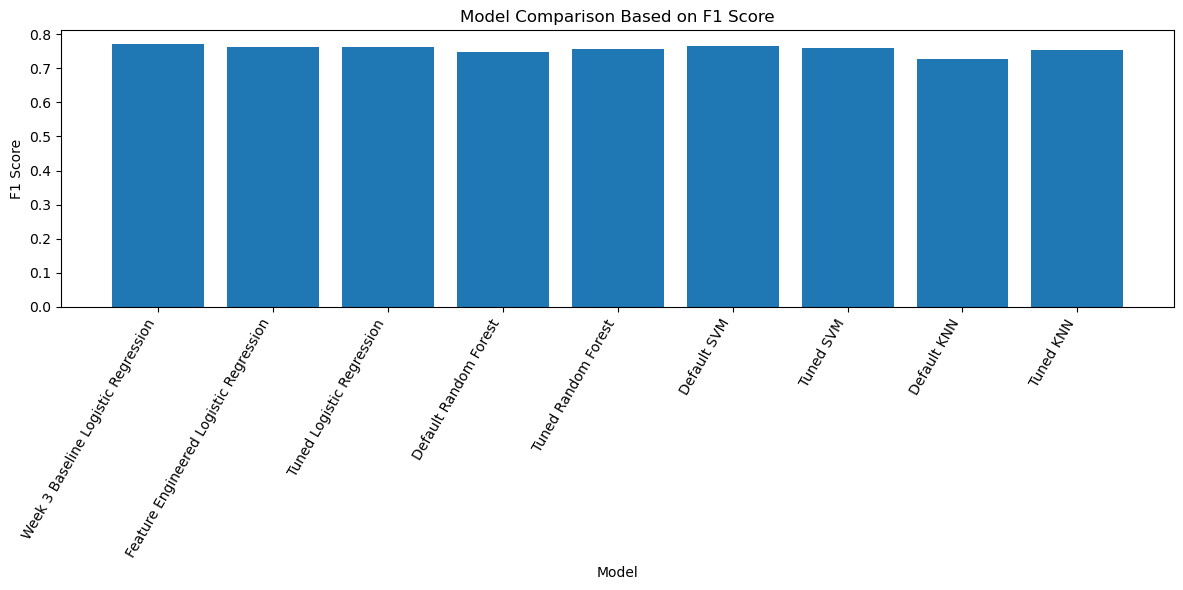

In [163]:
plt.figure(figsize=(12, 6))

plt.bar(
    final_results["Model"],
    final_results["F1 Score"]
)

plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.title("Model Comparison Based on F1 Score")

plt.xticks(rotation=60, ha="right")
plt.tight_layout()

plt.show()

===== FINAL MODEL CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

  Not Placed       0.84      0.83      0.83      1161
      Placed       0.77      0.78      0.77       839

    accuracy                           0.81      2000
   macro avg       0.80      0.80      0.80      2000
weighted avg       0.81      0.81      0.81      2000

===== FINAL CONFUSION MATRIX =====
[[966 195]
 [188 651]]


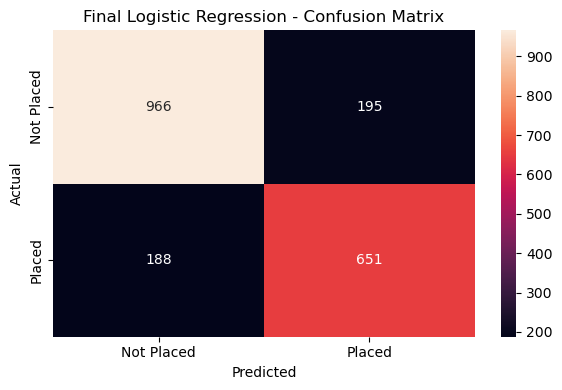

In [164]:
print("===== FINAL MODEL CLASSIFICATION REPORT =====")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Not Placed", "Placed"]
    )
)

final_cm = confusion_matrix(y_test, y_pred)

print("===== FINAL CONFUSION MATRIX =====")
print(final_cm)

plt.figure(figsize=(6, 4))

sns.heatmap(
    final_cm,
    annot=True,
    fmt="d",
    xticklabels=["Not Placed", "Placed"],
    yticklabels=["Not Placed", "Placed"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Final Logistic Regression - Confusion Matrix")

plt.tight_layout()
plt.show()

ROC-AUC Score: 0.8837


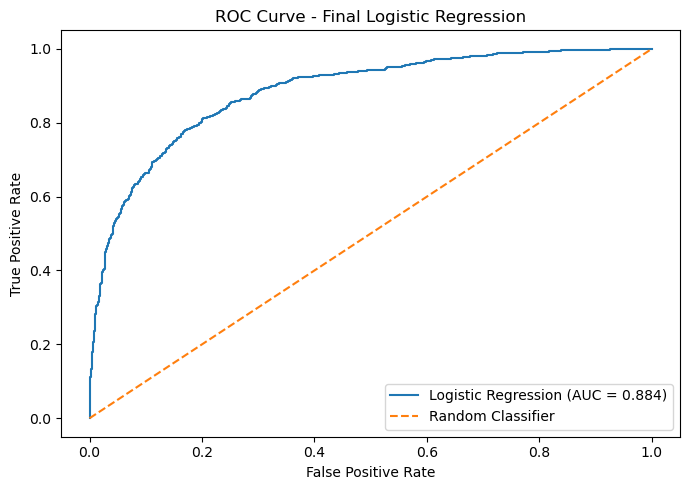

In [165]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = baseline_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc_score = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", round(auc_score, 4))

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {auc_score:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Final Logistic Regression")

plt.legend()
plt.tight_layout()
plt.show()

In [166]:
# Get the trained Logistic Regression model
lr_model = baseline_model.named_steps["classifier"]

# Get the preprocessing transformer
preprocessor_fitted = baseline_model.named_steps["preprocessor"]

# Get feature names after preprocessing
feature_names = preprocessor_fitted.get_feature_names_out()

# Get Logistic Regression coefficients
coefficients = lr_model.coef_[0]

# Create feature importance dataframe
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Absolute_Importance": np.abs(coefficients)
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by="Absolute_Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Coefficient,Absolute_Importance
10,cat__PlacementTraining_No,-0.661943,0.661943
4,num__AptitudeTestScore,0.610339,0.610339
8,cat__ExtracurricularActivities_No,-0.585779,0.585779
6,num__SSC_Marks,0.282377,0.282377
5,num__SoftSkillsRating,0.263395,0.263395
0,num__CGPA,0.257472,0.257472
2,num__Projects,0.254510,0.254510
7,num__HSC_Marks,0.221629,0.221629
11,cat__PlacementTraining_Yes,0.221419,0.221419
9,cat__ExtracurricularActivities_Yes,0.145255,0.145255


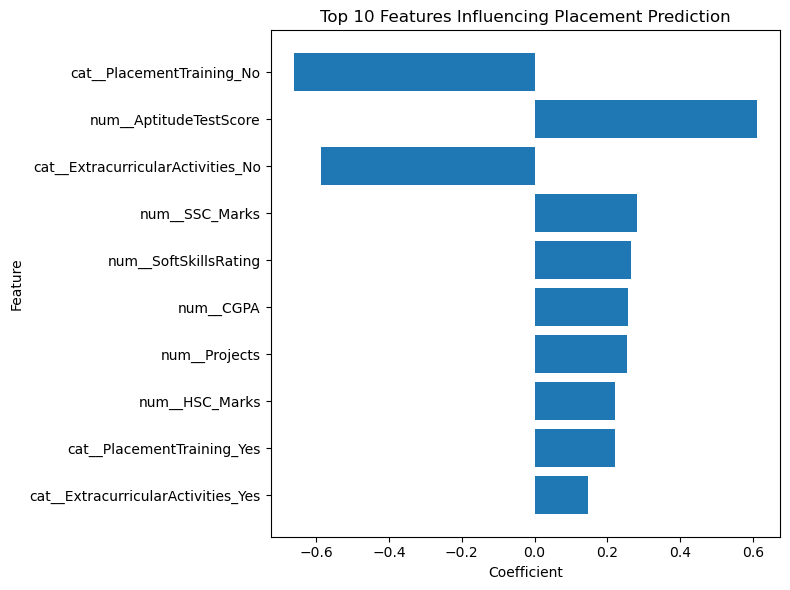

In [167]:
top_features = feature_importance.head(10).sort_values(
    by="Absolute_Importance"
)

plt.figure(figsize=(8, 6))

plt.barh(
    top_features["Feature"],
    top_features["Coefficient"]
)

plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Top 10 Features Influencing Placement Prediction")

plt.tight_layout()
plt.show()

In [171]:
# ============================================
# WEEK 5
# MODEL EVALUATION, VALIDATION & INTERPRETABILITY
# ============================================

print("============================================")
print("WEEK 5 - MODEL EVALUATION & INTERPRETABILITY")
print("============================================")

print("\nObjective:")
print("Evaluate the robustness, reliability and")
print("interpretability of the tuned Logistic Regression model.")

WEEK 5 - MODEL EVALUATION & INTERPRETABILITY

Objective:
Evaluate the robustness, reliability and
interpretability of the tuned Logistic Regression model.


In [172]:
# ============================================
# IMPORT LIBRARIES
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    cross_val_score,
    StratifiedKFold
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score
)

from sklearn.inspection import permutation_importance

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [173]:
# ============================================
# VERIFY WEEK 4 MODEL
# ============================================

print("Best Logistic Regression Model:")
print(best_lr)

print("\nBest Parameters:")
print(grid_lr.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(round(grid_lr.best_score_, 4))

Best Logistic Regression Model:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('interaction',
                                                                   PolynomialFeatures(include_bias=False,
                                                                                      interaction_only=True)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['CGPA', 'Internships', 'Projects', 'Workshops/Certifications',
       'AptitudeTestScore', 'SoftSkillsRating', 'SSC_Marks', 'HSC_Marks'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                

In [174]:
# ============================================
# FINAL TEST PREDICTIONS
# ============================================

y_pred_tuned_lr = best_lr.predict(X_test)

print("Predictions generated successfully!")
print("Number of predictions:", len(y_pred_tuned_lr))

Predictions generated successfully!
Number of predictions: 2000


In [175]:
# ============================================
# PREDICTION PROBABILITIES
# ============================================

y_prob_tuned_lr = best_lr.predict_proba(X_test)[:, 1]

print("Prediction probabilities generated successfully!")

print("\nFirst 10 probabilities:")
print(y_prob_tuned_lr[:10])

Prediction probabilities generated successfully!

First 10 probabilities:
[0.14225549 0.03384041 0.86890916 0.13614272 0.55460618 0.68843688
 0.07131121 0.56568605 0.33063449 0.62547698]


In [176]:
# ============================================
# BASIC PERFORMANCE METRICS
# ============================================

week5_accuracy = accuracy_score(
    y_test,
    y_pred_tuned_lr
)

week5_precision = precision_score(
    y_test,
    y_pred_tuned_lr,
    zero_division=0
)

week5_recall = recall_score(
    y_test,
    y_pred_tuned_lr,
    zero_division=0
)

week5_f1 = f1_score(
    y_test,
    y_pred_tuned_lr,
    zero_division=0
)

week5_auc = roc_auc_score(
    y_test,
    y_prob_tuned_lr
)

week5_ap = average_precision_score(
    y_test,
    y_prob_tuned_lr
)

print("============================================")
print("WEEK 5 PERFORMANCE METRICS")
print("============================================")

print("Accuracy :", round(week5_accuracy * 100, 2), "%")
print("Precision:", round(week5_precision * 100, 2), "%")
print("Recall   :", round(week5_recall * 100, 2), "%")
print("F1 Score :", round(week5_f1 * 100, 2), "%")
print("ROC-AUC  :", round(week5_auc, 4))
print("Average Precision:", round(week5_ap, 4))

WEEK 5 PERFORMANCE METRICS
Accuracy : 80.2 %
Precision: 77.05 %
Recall   : 75.21 %
F1 Score : 76.12 %
ROC-AUC  : 0.8816
Average Precision: 0.8491


In [177]:
# ============================================
# CLASSIFICATION REPORT
# ============================================

print("============================================")
print("CLASSIFICATION REPORT")
print("============================================")

print(
    classification_report(
        y_test,
        y_pred_tuned_lr,
        zero_division=0
    )
)

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.82      0.84      0.83      1161
           1       0.77      0.75      0.76       839

    accuracy                           0.80      2000
   macro avg       0.80      0.80      0.80      2000
weighted avg       0.80      0.80      0.80      2000



In [178]:
# ============================================
# CONFUSION MATRIX
# ============================================

cm = confusion_matrix(
    y_test,
    y_pred_tuned_lr
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[973 188]
 [208 631]]


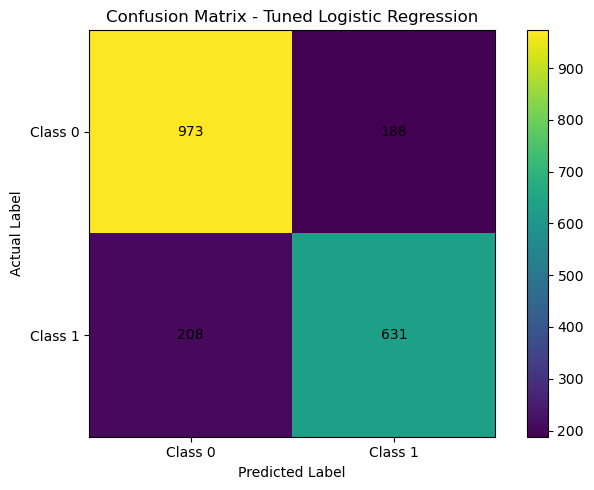

In [179]:
# ============================================
# CONFUSION MATRIX VISUALIZATION
# ============================================

plt.figure(figsize=(7, 5))

plt.imshow(cm)

plt.title("Confusion Matrix - Tuned Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks(
    [0, 1],
    ["Class 0", "Class 1"]
)

plt.yticks(
    [0, 1],
    ["Class 0", "Class 1"]
)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()

plt.tight_layout()
plt.show()

In [180]:
# ============================================
# CONFUSION MATRIX COMPONENTS
# ============================================

tn, fp, fn, tp = cm.ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

True Negatives : 973
False Positives: 188
False Negatives: 208
True Positives : 631


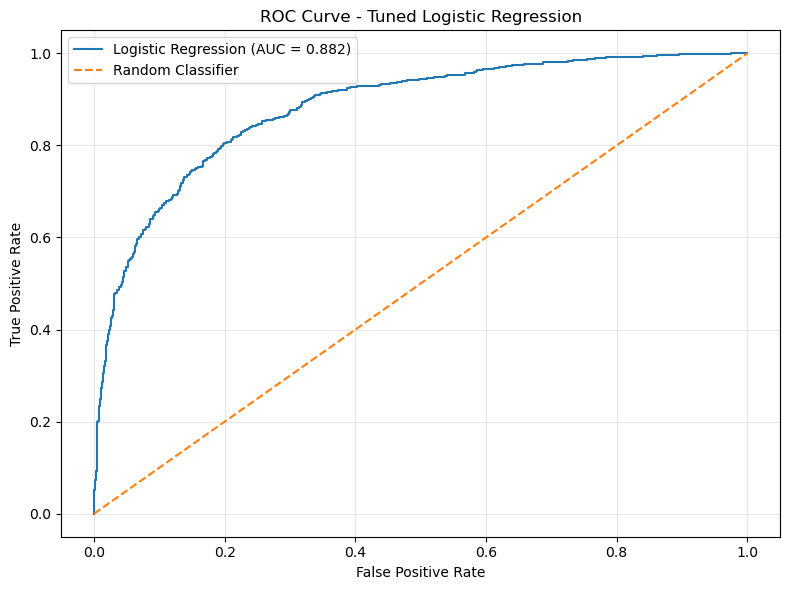

In [181]:
# ============================================
# ROC CURVE
# ============================================

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob_tuned_lr
)

roc_auc = roc_auc_score(
    y_test,
    y_prob_tuned_lr
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Tuned Logistic Regression")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

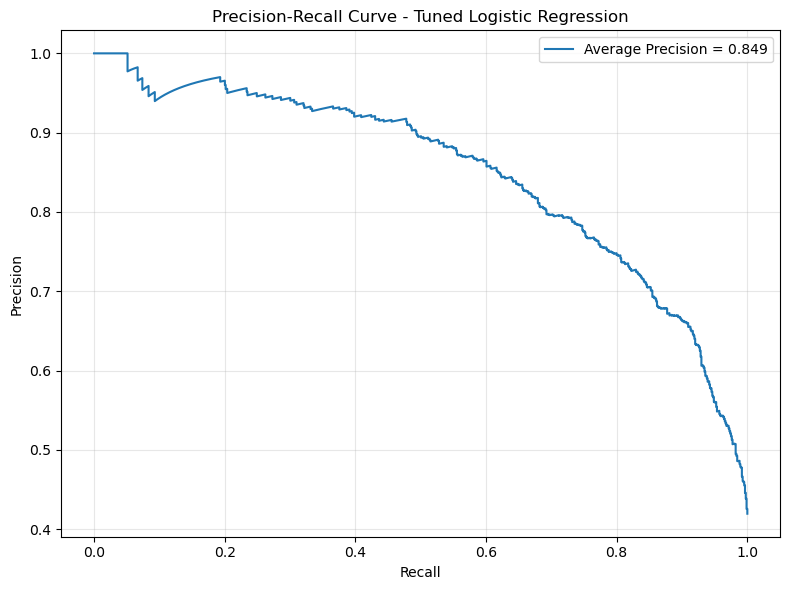

In [182]:
# ============================================
# PRECISION-RECALL CURVE
# ============================================

precision_values, recall_values, pr_thresholds = (
    precision_recall_curve(
        y_test,
        y_prob_tuned_lr
    )
)

average_precision = average_precision_score(
    y_test,
    y_prob_tuned_lr
)

plt.figure(figsize=(8, 6))

plt.plot(
    recall_values,
    precision_values,
    label=f"Average Precision = {average_precision:.3f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    "Precision-Recall Curve - Tuned Logistic Regression"
)

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [183]:
# ============================================
# STRATIFIED CROSS-VALIDATION
# ============================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_f1_scores = cross_val_score(
    best_lr,
    X_train,
    y_train,
    cv=cv,
    scoring="f1",
    n_jobs=1
)

print("Cross-Validation F1 Scores:")
print(cv_f1_scores)

print("\nMean CV F1 Score:")
print(round(cv_f1_scores.mean(), 4))

print("\nStandard Deviation:")
print(round(cv_f1_scores.std(), 4))

Cross-Validation F1 Scores:
[0.74730354 0.72330827 0.75471698 0.76730486 0.78345865]

Mean CV F1 Score:
0.7552

Standard Deviation:
0.0201


In [184]:
# ============================================
# CROSS-VALIDATION ACCURACY
# ============================================

cv_accuracy_scores = cross_val_score(
    best_lr,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy",
    n_jobs=1
)

print("Cross-Validation Accuracy Scores:")
print(cv_accuracy_scores)

print("\nMean Accuracy:")
print(round(cv_accuracy_scores.mean(), 4))

print("\nStandard Deviation:")
print(round(cv_accuracy_scores.std(), 4))

Cross-Validation Accuracy Scores:
[0.795    0.77     0.796875 0.8025   0.82    ]

Mean Accuracy:
0.7969

Standard Deviation:
0.0161


In [185]:
# ============================================
# CROSS-VALIDATION PRECISION
# ============================================

cv_precision_scores = cross_val_score(
    best_lr,
    X_train,
    y_train,
    cv=cv,
    scoring="precision",
    n_jobs=1
)

print("Precision Scores:")
print(cv_precision_scores)

print("\nMean Precision:")
print(round(cv_precision_scores.mean(), 4))

Precision Scores:
[0.77352472 0.72989378 0.76569678 0.75947522 0.79179331]

Mean Precision:
0.7641


In [186]:
# ============================================
# CROSS-VALIDATION RECALL
# ============================================

cv_recall_scores = cross_val_score(
    best_lr,
    X_train,
    y_train,
    cv=cv,
    scoring="recall",
    n_jobs=1
)

print("Recall Scores:")
print(cv_recall_scores)

print("\nMean Recall:")
print(round(cv_recall_scores.mean(), 4))

Recall Scores:
[0.72280179 0.71684054 0.74404762 0.77529762 0.77529762]

Mean Recall:
0.7469


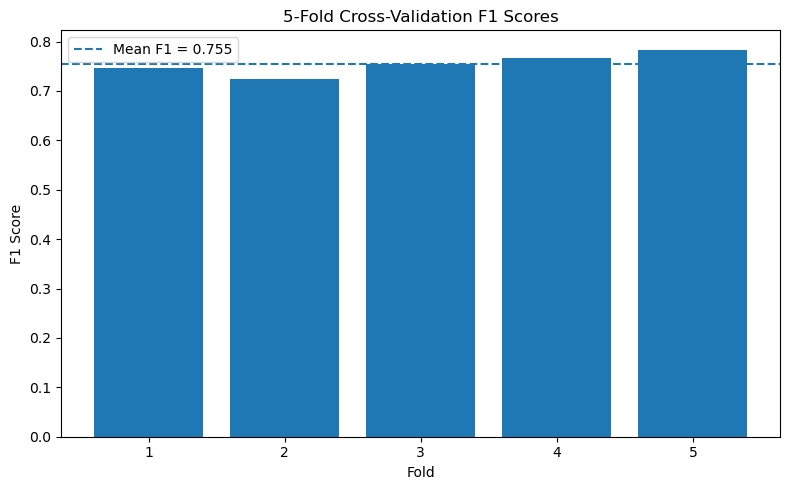

In [187]:
# ============================================
# CROSS-VALIDATION F1 VISUALIZATION
# ============================================

fold_numbers = np.arange(
    1,
    len(cv_f1_scores) + 1
)

plt.figure(figsize=(8, 5))

plt.bar(
    fold_numbers,
    cv_f1_scores
)

plt.axhline(
    cv_f1_scores.mean(),
    linestyle="--",
    label=f"Mean F1 = {cv_f1_scores.mean():.3f}"
)

plt.xlabel("Fold")
plt.ylabel("F1 Score")

plt.title(
    "5-Fold Cross-Validation F1 Scores"
)

plt.xticks(fold_numbers)

plt.legend()

plt.tight_layout()
plt.show()

In [188]:
# ============================================
# BOOTSTRAP VALIDATION
# ============================================

rng = np.random.RandomState(42)

n_bootstrap = 1000

bootstrap_accuracy = []
bootstrap_f1 = []

y_test_array = np.array(y_test)
y_pred_array = np.array(y_pred_tuned_lr)

for i in range(n_bootstrap):

    indices = rng.randint(
        0,
        len(y_test_array),
        len(y_test_array)
    )

    y_true_sample = y_test_array[indices]
    y_pred_sample = y_pred_array[indices]

    bootstrap_accuracy.append(
        accuracy_score(
            y_true_sample,
            y_pred_sample
        )
    )

    bootstrap_f1.append(
        f1_score(
            y_true_sample,
            y_pred_sample,
            zero_division=0
        )
    )

print("Bootstrap evaluation completed!")
print("Number of bootstrap samples:", n_bootstrap)

Bootstrap evaluation completed!
Number of bootstrap samples: 1000


In [189]:
# ============================================
# BOOTSTRAP CONFIDENCE INTERVALS
# ============================================

accuracy_lower = np.percentile(
    bootstrap_accuracy,
    2.5
)

accuracy_upper = np.percentile(
    bootstrap_accuracy,
    97.5
)

f1_lower = np.percentile(
    bootstrap_f1,
    2.5
)

f1_upper = np.percentile(
    bootstrap_f1,
    97.5
)

print("============================================")
print("BOOTSTRAP 95% CONFIDENCE INTERVALS")
print("============================================")

print(
    "Accuracy:",
    round(np.mean(bootstrap_accuracy), 4),
    "(",
    round(accuracy_lower, 4),
    "-",
    round(accuracy_upper, 4),
    ")"
)

print(
    "F1 Score:",
    round(np.mean(bootstrap_f1), 4),
    "(",
    round(f1_lower, 4),
    "-",
    round(f1_upper, 4),
    ")"
)

BOOTSTRAP 95% CONFIDENCE INTERVALS
Accuracy: 0.8019 ( 0.7845 - 0.8195 )
F1 Score: 0.761 ( 0.7378 - 0.7831 )


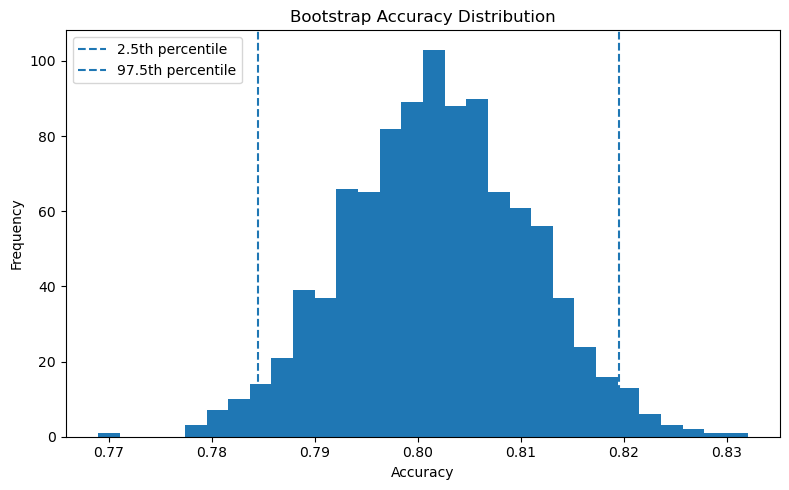

In [190]:
# ============================================
# BOOTSTRAP DISTRIBUTION - ACCURACY
# ============================================

plt.figure(figsize=(8, 5))

plt.hist(
    bootstrap_accuracy,
    bins=30
)

plt.axvline(
    accuracy_lower,
    linestyle="--",
    label="2.5th percentile"
)

plt.axvline(
    accuracy_upper,
    linestyle="--",
    label="97.5th percentile"
)

plt.xlabel("Accuracy")
plt.ylabel("Frequency")

plt.title(
    "Bootstrap Accuracy Distribution"
)

plt.legend()

plt.tight_layout()
plt.show()

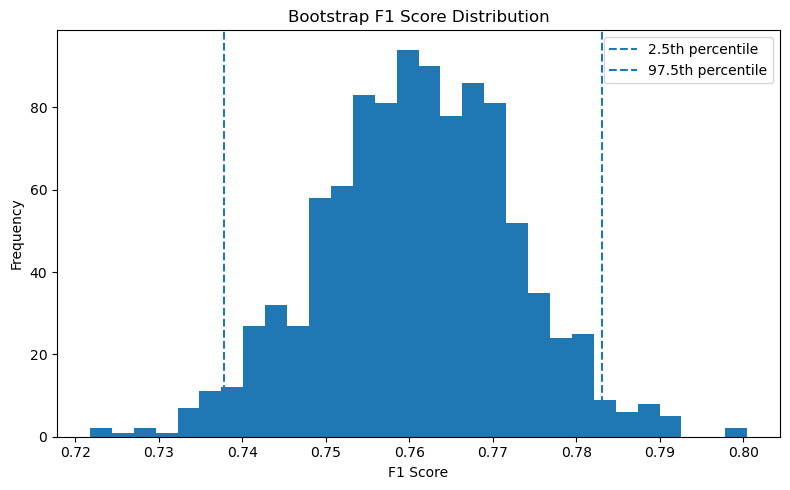

In [191]:
# ============================================
# BOOTSTRAP DISTRIBUTION - F1
# ============================================

plt.figure(figsize=(8, 5))

plt.hist(
    bootstrap_f1,
    bins=30
)

plt.axvline(
    f1_lower,
    linestyle="--",
    label="2.5th percentile"
)

plt.axvline(
    f1_upper,
    linestyle="--",
    label="97.5th percentile"
)

plt.xlabel("F1 Score")
plt.ylabel("Frequency")

plt.title(
    "Bootstrap F1 Score Distribution"
)

plt.legend()

plt.tight_layout()
plt.show()

In [192]:
# ============================================
# MODEL STABILITY SUMMARY
# ============================================

print("============================================")
print("MODEL STABILITY SUMMARY")
print("============================================")

print(
    "Mean CV F1:",
    round(cv_f1_scores.mean(), 4)
)

print(
    "CV F1 Std:",
    round(cv_f1_scores.std(), 4)
)

print(
    "Bootstrap Accuracy:",
    round(np.mean(bootstrap_accuracy), 4)
)

print(
    "Bootstrap Accuracy 95% CI:",
    round(accuracy_lower, 4),
    "-",
    round(accuracy_upper, 4)
)

print(
    "Bootstrap F1:",
    round(np.mean(bootstrap_f1), 4)
)

print(
    "Bootstrap F1 95% CI:",
    round(f1_lower, 4),
    "-",
    round(f1_upper, 4)
)

MODEL STABILITY SUMMARY
Mean CV F1: 0.7552
CV F1 Std: 0.0201
Bootstrap Accuracy: 0.8019
Bootstrap Accuracy 95% CI: 0.7845 - 0.8195
Bootstrap F1: 0.761
Bootstrap F1 95% CI: 0.7378 - 0.7831


In [193]:
# ============================================
# PERMUTATION FEATURE IMPORTANCE
# ============================================

print("Calculating permutation importance...")

perm_result = permutation_importance(
    best_lr,
    X_test,
    y_test,
    scoring="f1",
    n_repeats=10,
    random_state=42,
    n_jobs=1
)

print("Permutation importance calculated!")

Calculating permutation importance...
Permutation importance calculated!


In [194]:
# ============================================
# GET FEATURE NAMES
# ============================================

if hasattr(X_test, "columns"):
    feature_names = X_test.columns.to_numpy()
else:
    feature_names = np.array(
        [f"Feature_{i}" for i in range(X_test.shape[1])]
    )

print("Number of features:", len(feature_names))
print("First few feature names:")
print(feature_names[:10])

Number of features: 10
First few feature names:
['CGPA' 'Internships' 'Projects' 'Workshops/Certifications'
 'AptitudeTestScore' 'SoftSkillsRating' 'ExtracurricularActivities'
 'PlacementTraining' 'SSC_Marks' 'HSC_Marks']


In [195]:
# ============================================
# FEATURE IMPORTANCE TABLE
# ============================================

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance_Mean": perm_result.importances_mean,
    "Importance_Std": perm_result.importances_std
})

importance_df = importance_df.sort_values(
    by="Importance_Mean",
    ascending=False
)

print("Top 15 Important Features:")
display(
    importance_df.head(15)
)

Top 15 Important Features:


,Feature,Importance_Mean,Importance_Std
4,AptitudeTestScore,0.053266,0.007746
6,ExtracurricularActivities,0.014847,0.003614
7,PlacementTraining,0.014409,0.003566
8,SSC_Marks,0.013261,0.005087
5,SoftSkillsRating,0.008410,0.003713
9,HSC_Marks,0.005890,0.004287
2,Projects,0.002837,0.003021
3,Workshops/Certifications,0.001151,0.002113
0,CGPA,0.000510,0.003892
1,Internships,-0.002829,0.001576


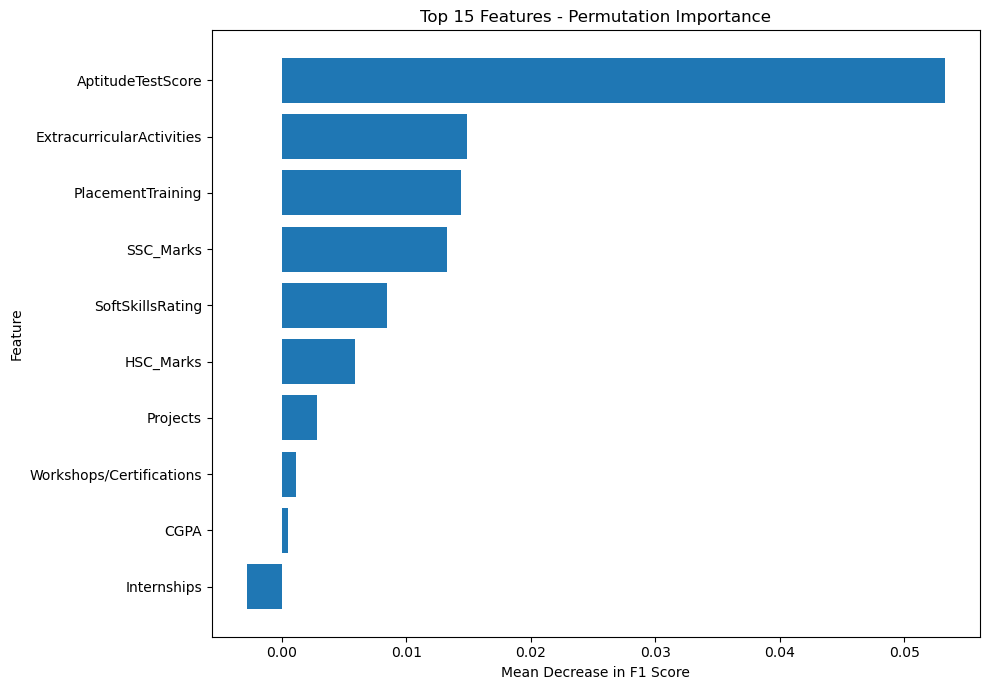

In [196]:
# ============================================
# FEATURE IMPORTANCE VISUALIZATION
# ============================================

top_features = importance_df.head(15)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance_Mean"][::-1]
)

plt.xlabel("Mean Decrease in F1 Score")

plt.ylabel("Feature")

plt.title(
    "Top 15 Features - Permutation Importance"
)

plt.tight_layout()
plt.show()

In [197]:
# ============================================
# FIND LOGISTIC REGRESSION CLASSIFIER
# ============================================

if hasattr(best_lr, "named_steps"):
    
    classifier = best_lr.named_steps["classifier"]

else:
    
    classifier = best_lr

print("Classifier:")
print(classifier)

Classifier:
LogisticRegression(C=1, max_iter=2000, solver='liblinear')


In [198]:
# ============================================
# LOGISTIC REGRESSION COEFFICIENTS
# ============================================

coefficients = classifier.coef_[0]

print("Number of coefficients:", len(coefficients))

Number of coefficients: 40


In [199]:
if len(feature_names) == len(coefficients):

    coefficient_df = pd.DataFrame({
        "Feature": feature_names,
        "Coefficient": coefficients,
        "Absolute_Coefficient": np.abs(coefficients)
    })

    coefficient_df = coefficient_df.sort_values(
        by="Absolute_Coefficient",
        ascending=False
    )

    print("Top features by coefficient magnitude:")
    display(
        coefficient_df.head(15)
    )

else:

    print(
        "Number of original features does not match "
        "number of transformed features."
    )

Number of original features does not match number of transformed features.


In [203]:
# ============================================
# POSITIVE AND NEGATIVE COEFFICIENTS
# ============================================

if len(feature_names) == len(coefficients):

    positive_coefficients = (
        coefficient_df
        .sort_values(
            by="Coefficient",
            ascending=False
        )
        .head(10)
    )

    negative_coefficients = (
        coefficient_df
        .sort_values(
            by="Coefficient",
            ascending=True
        )
        .head(10)
    )

    print("===== POSITIVE COEFFICIENTS =====")
    display(positive_coefficients)

    print("\n===== NEGATIVE COEFFICIENTS =====")
    display(negative_coefficients)

In [204]:
# ============================================
# SHAP
# ============================================

!pip install shap
# ============================================
# IMPORT SHAP
# ============================================

import shap

print("SHAP version:", shap.__version__)
print("SHAP imported successfully!")


   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]

SHAP version: 0.52.0
SHAP imported successfully!


In [205]:
# ============================================
# EXTRACT PREPROCESSOR
# ============================================

print("Pipeline steps:")

if hasattr(best_lr, "named_steps"):
    print(best_lr.named_steps.keys())
else:
    print("Model is not a Pipeline.")

Pipeline steps:
dict_keys(['preprocessor', 'classifier'])


In [206]:
preprocessor = best_lr.named_steps["preprocessor"]

print("Preprocessor extracted successfully!")

Preprocessor extracted successfully!


In [207]:
# ============================================
# TRANSFORM DATA FOR SHAP
# ============================================

X_train_transformed = preprocessor.transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

print(
    "Transformed training shape:",
    X_train_transformed.shape
)

print(
    "Transformed testing shape:",
    X_test_transformed.shape
)

Transformed training shape: (8000, 40)
Transformed testing shape: (2000, 40)


In [208]:
# ============================================
# TRANSFORMED FEATURE NAMES
# ============================================

try:

    transformed_feature_names = (
        preprocessor.get_feature_names_out()
    )

    print(
        "Number of transformed features:",
        len(transformed_feature_names)
    )

    print(
        "\nFirst 20 transformed features:"
    )

    print(
        transformed_feature_names[:20]
    )

except Exception as e:

    print("Could not automatically obtain feature names.")
    print("Reason:", e)

    transformed_feature_names = np.array(
        [
            f"Feature_{i}"
            for i in range(
                X_train_transformed.shape[1]
            )
        ]
    )

Number of transformed features: 40

First 20 transformed features:
['num__CGPA' 'num__Internships' 'num__Projects'
 'num__Workshops/Certifications' 'num__AptitudeTestScore'
 'num__SoftSkillsRating' 'num__SSC_Marks' 'num__HSC_Marks'
 'num__CGPA Internships' 'num__CGPA Projects'
 'num__CGPA Workshops/Certifications' 'num__CGPA AptitudeTestScore'
 'num__CGPA SoftSkillsRating' 'num__CGPA SSC_Marks' 'num__CGPA HSC_Marks'
 'num__Internships Projects' 'num__Internships Workshops/Certifications'
 'num__Internships AptitudeTestScore' 'num__Internships SoftSkillsRating'
 'num__Internships SSC_Marks']


In [209]:
# ============================================
# SHAP LINEAR EXPLAINER
# ============================================

# Use a smaller background sample to keep computation efficient

if hasattr(X_train_transformed, "toarray"):
    background = X_train_transformed[:100].toarray()
    X_test_shap = X_test_transformed[:100].toarray()
else:
    background = X_train_transformed[:100]
    X_test_shap = X_test_transformed[:100]

explainer = shap.LinearExplainer(
    classifier,
    background
)

shap_values = explainer(
    X_test_shap
)

print("SHAP values calculated successfully!")

SHAP values calculated successfully!


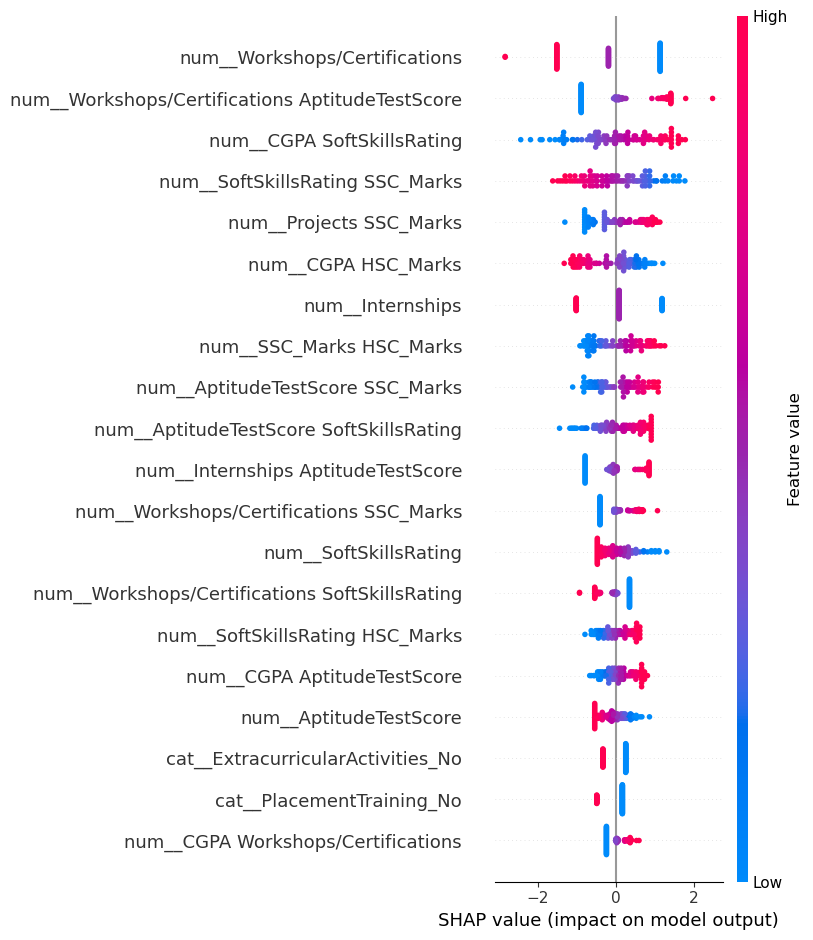

In [210]:
# ============================================
# SHAP SUMMARY PLOT
# ============================================

shap.summary_plot(
    shap_values,
    X_test_shap,
    feature_names=transformed_feature_names,
    show=True
)

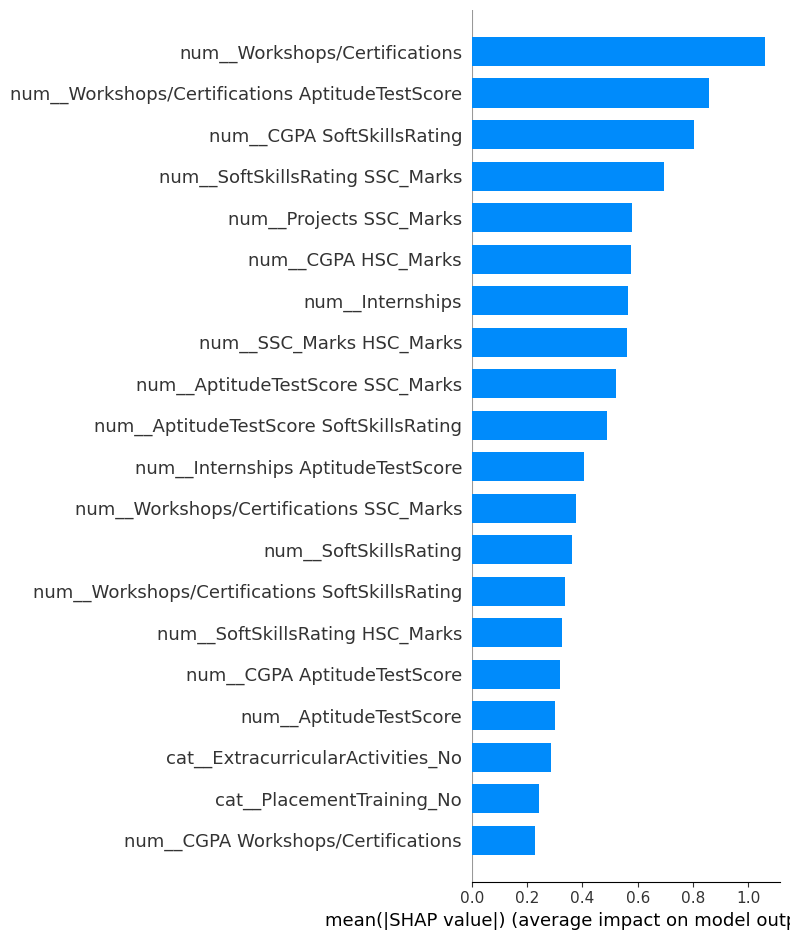

In [211]:
# ============================================
# SHAP FEATURE IMPORTANCE
# ============================================

shap.summary_plot(
    shap_values,
    X_test_shap,
    feature_names=transformed_feature_names,
    plot_type="bar",
    show=True
)

Explaining test sample: 0


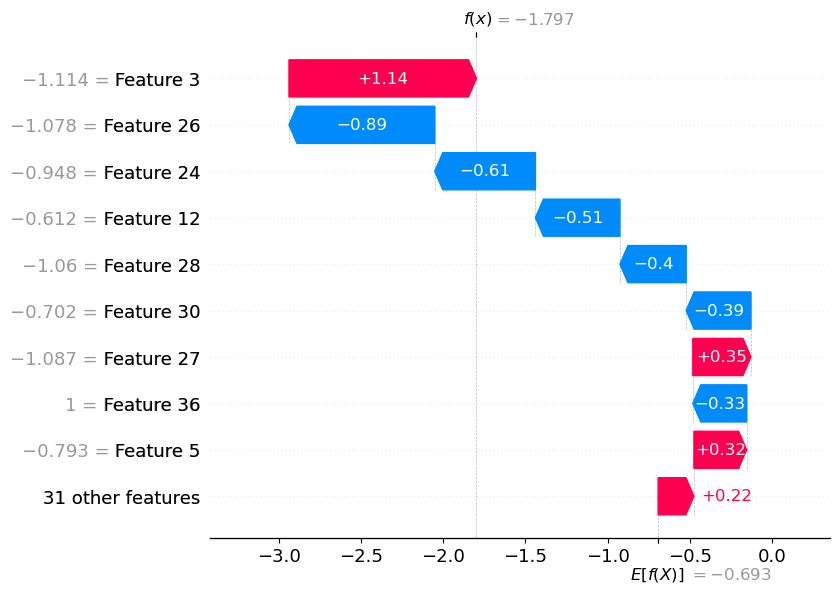

In [212]:
# ============================================
# INDIVIDUAL SHAP EXPLANATION
# ============================================

sample_index = 0

print(
    "Explaining test sample:",
    sample_index
)

shap.plots.waterfall(
    shap_values[sample_index]
)

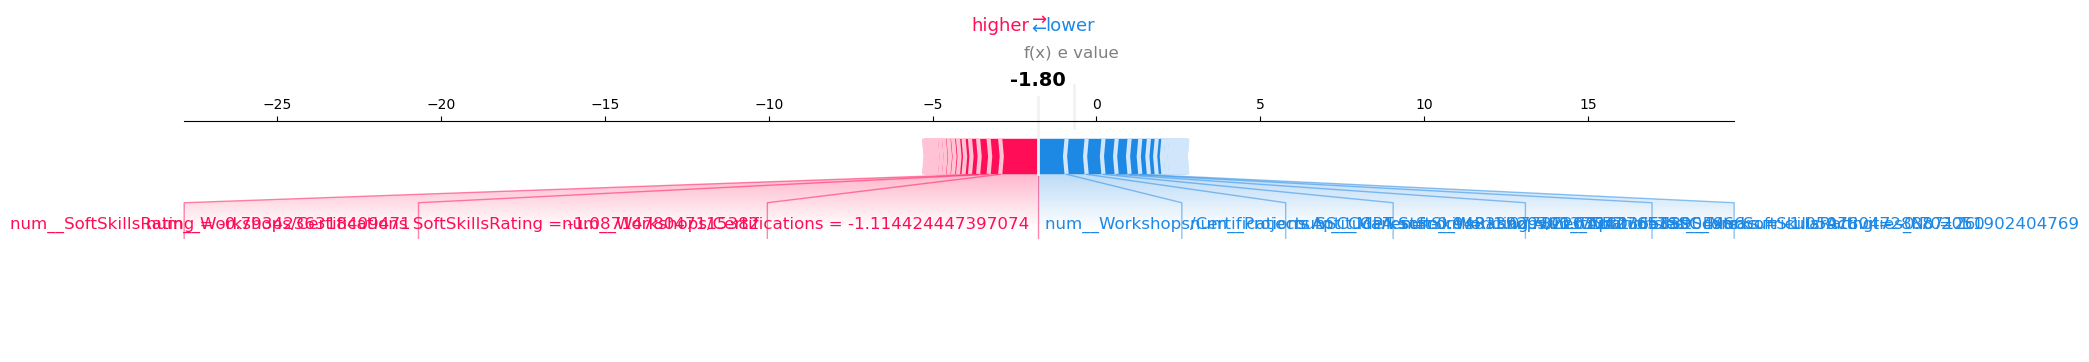

<Figure size 640x480 with 0 Axes>

In [213]:
# ============================================
# SHAP FORCE PLOT
# ============================================

shap.force_plot(
    explainer.expected_value,
    shap_values.values[0],
    X_test_shap[0],
    feature_names=transformed_feature_names,
    matplotlib=True
)

plt.tight_layout()
plt.show()

In [214]:
# ============================================
# WEEK 4 vs WEEK 5 PERFORMANCE
# ============================================

comparison_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],

    "Tuned Logistic Regression": [
        week5_accuracy,
        week5_precision,
        week5_recall,
        week5_f1,
        week5_auc
    ]
})

comparison_df["Percentage"] = (
    comparison_df["Tuned Logistic Regression"] * 100
)

display(comparison_df)

,Metric,Tuned Logistic Regression,Percentage
0,Accuracy,0.802000,80.200000
1,Precision,0.770452,77.045177
2,Recall,0.752086,75.208582
3,F1 Score,0.761158,76.115802
4,ROC-AUC,0.881625,88.162459


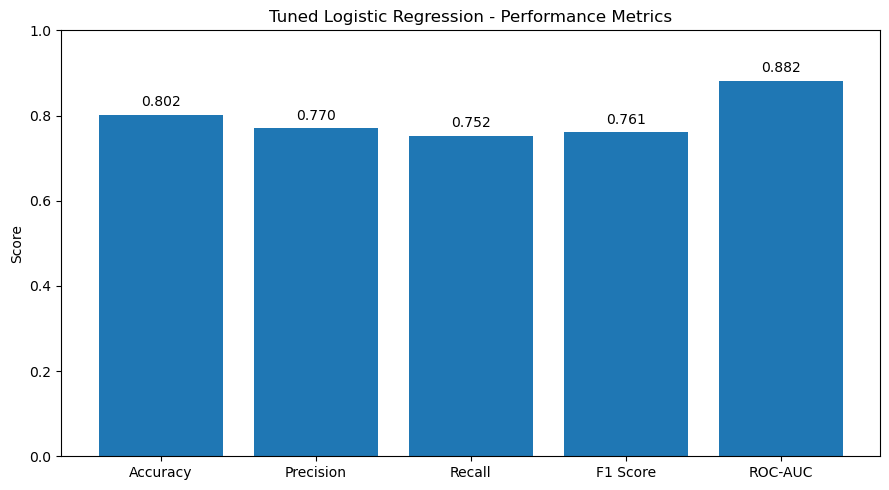

In [215]:
# ============================================
# PERFORMANCE METRICS VISUALIZATION
# ============================================

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC"
]

values = [
    week5_accuracy,
    week5_precision,
    week5_recall,
    week5_f1,
    week5_auc
]

plt.figure(figsize=(9, 5))

plt.bar(
    metrics,
    values
)

plt.ylim(0, 1)

plt.ylabel("Score")

plt.title(
    "Tuned Logistic Regression - Performance Metrics"
)

for i, value in enumerate(values):

    plt.text(
        i,
        value + 0.02,
        f"{value:.3f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [216]:
# ============================================
# FINAL WEEK 5 RESULTS
# ============================================

final_results = pd.DataFrame({
    "Evaluation": [
        "Test Accuracy",
        "Test Precision",
        "Test Recall",
        "Test F1",
        "Test ROC-AUC",
        "Mean CV Accuracy",
        "Mean CV F1",
        "CV F1 Std",
        "Bootstrap Accuracy Mean",
        "Bootstrap Accuracy Lower 95%",
        "Bootstrap Accuracy Upper 95%",
        "Bootstrap F1 Mean",
        "Bootstrap F1 Lower 95%",
        "Bootstrap F1 Upper 95%"
    ],

    "Value": [
        week5_accuracy,
        week5_precision,
        week5_recall,
        week5_f1,
        week5_auc,
        cv_accuracy_scores.mean(),
        cv_f1_scores.mean(),
        cv_f1_scores.std(),
        np.mean(bootstrap_accuracy),
        accuracy_lower,
        accuracy_upper,
        np.mean(bootstrap_f1),
        f1_lower,
        f1_upper
    ]
})

display(final_results)

The history saving thread hit an unexpected error (OperationalError('database or disk is full')).History will not be written to the database.


,Evaluation,Value
0,Test Accuracy,0.802000
1,Test Precision,0.770452
2,Test Recall,0.752086
3,Test F1,0.761158
4,Test ROC-AUC,0.881625
5,Mean CV Accuracy,0.796875
6,Mean CV F1,0.755218
7,CV F1 Std,0.020123
8,Bootstrap Accuracy Mean,0.801865
9,Bootstrap Accuracy Lower 95%,0.784500


In [217]:
# ============================================
# SAVE FINAL RESULTS
# ============================================

final_results.to_csv(
    "week5_final_results.csv",
    index=False
)

importance_df.to_csv(
    "week5_feature_importance.csv",
    index=False
)

print("Results saved successfully!")

OSError: [Errno 28] No space left on device

In [218]:
# ============================================
# SAVE CROSS-VALIDATION RESULTS
# ============================================

cv_results_df = pd.DataFrame({
    "Fold": range(1, 6),
    "F1_Score": cv_f1_scores,
    "Accuracy": cv_accuracy_scores,
    "Precision": cv_precision_scores,
    "Recall": cv_recall_scores
})

display(cv_results_df)

cv_results_df.to_csv(
    "week5_cross_validation_results.csv",
    index=False
)

print("Cross-validation results saved!")

,Fold,F1_Score,Accuracy,Precision,Recall
0,1,0.747304,0.795000,0.773525,0.722802
1,2,0.723308,0.770000,0.729894,0.716841
2,3,0.754717,0.796875,0.765697,0.744048
3,4,0.767305,0.802500,0.759475,0.775298
4,5,0.783459,0.820000,0.791793,0.775298


Cross-validation results saved!


In [219]:
# ============================================
# AUTOMATIC MODEL ASSESSMENT
# ============================================

print("============================================")
print("WEEK 5 MODEL ASSESSMENT")
print("============================================")

print(
    f"\nThe tuned Logistic Regression achieved "
    f"an F1 score of {week5_f1:.3f} on the test set."
)

print(
    f"The ROC-AUC score was {week5_auc:.3f}, "
    f"indicating the model's ability to distinguish "
    f"between the two classes."
)

print(
    f"\nThe mean 5-fold cross-validation F1 score was "
    f"{cv_f1_scores.mean():.3f} "
    f"with a standard deviation of "
    f"{cv_f1_scores.std():.3f}."
)

print(
    f"\nBootstrap analysis estimated an accuracy of "
    f"{np.mean(bootstrap_accuracy):.3f} "
    f"with a 95% confidence interval from "
    f"{accuracy_lower:.3f} to {accuracy_upper:.3f}."
)

print(
    f"\nThe bootstrap F1 score was approximately "
    f"{np.mean(bootstrap_f1):.3f}, "
    f"with a 95% confidence interval from "
    f"{f1_lower:.3f} to {f1_upper:.3f}."
)

WEEK 5 MODEL ASSESSMENT

The tuned Logistic Regression achieved an F1 score of 0.761 on the test set.
The ROC-AUC score was 0.882, indicating the model's ability to distinguish between the two classes.

The mean 5-fold cross-validation F1 score was 0.755 with a standard deviation of 0.020.

Bootstrap analysis estimated an accuracy of 0.802 with a 95% confidence interval from 0.784 to 0.820.

The bootstrap F1 score was approximately 0.761, with a 95% confidence interval from 0.738 to 0.783.
